In [5]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import pandas as pd
import os

In [6]:
df = xr.open_dataset("HC_1995-2014.nc", engine="netcdf4")
var_soilm = df["H2OSOI"]
var_soilm

C:\Users\madel\AppData\Local\Temp\ipykernel_10460\155507039.py:1: FutureWarning: In a future version, xarray will not decode the variable 'SNOW_PERSISTENCE' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.
  df = xr.open_dataset("HC_1995-2014.nc", engine="netcdf4")


<xarray.DataArray 'H2OSOI' (time: 7300, levsoi: 20, lndgrid: 1)> Size: 584kB
[146000 values with dtype=float32]
Coordinates:
  * time     (time) object 58kB 1995-01-01 00:00:00 ... 2014-12-31 00:00:00
  * levsoi   (levsoi) float32 80B 0.01 0.04 0.09 0.16 ... 5.06 5.95 6.94 8.03
Dimensions without coordinates: lndgrid
Attributes:
    long_name:      volumetric soil water (natural vegetated and crop landuni...
    units:          mm3/mm3
    cell_methods:   time: mean
    landunit_mask:  veg

In [7]:
def obs_data_parse(file):
    obs = pd.read_csv(
    f"{file}",   # just change the extension
    comment="#",
    sep=r"\s+|,|\t",
    parse_dates=["Timestamp"],
    engine="python"
    )
    obs.rename(columns={"Timestamp": "time", "Value": "obs_m"}, inplace=True)
    return obs

In [8]:
# Input ypur path to all observational values
# Makes a simple list for now but could definitely be a dictionary later
directory_path = "HC_obs/soil_moisture"
observe = {}

for filename in os.listdir(directory_path):
    # Join the directory path and the filename to get the full file path
    full_path = os.path.join(directory_path, filename)
    # Check if it is a file (not a directory)
    if os.path.isfile(full_path):
        df = obs_data_parse(full_path)
        observe.update({f"{filename}":df})

In [9]:
for x in observe:
  print(observe[x]) 

                           time  obs_m
0     1998-08-24 02:30:00+00:00  1.300
1     1998-08-24 03:00:00+00:00  1.300
2     1998-08-24 03:30:00+00:00  1.300
3     1998-08-24 04:00:00+00:00  1.300
4     1998-08-24 04:30:00+00:00  1.300
...                         ...    ...
23765 2000-01-01 05:00:00+00:00  0.815
23766 2000-01-01 05:30:00+00:00  0.815
23767 2000-01-01 06:00:00+00:00  0.815
23768 2000-01-01 06:30:00+00:00  0.815
23769 2000-01-01 07:00:00+00:00  0.815

[23770 rows x 2 columns]
                           time  obs_m
0     1998-08-24 02:30:00+00:00  0.420
1     1998-08-24 03:00:00+00:00  0.430
2     1998-08-24 03:30:00+00:00  0.420
3     1998-08-24 04:00:00+00:00  0.430
4     1998-08-24 04:30:00+00:00  0.430
...                         ...    ...
23765 2000-01-01 05:00:00+00:00  0.066
23766 2000-01-01 05:30:00+00:00  0.066
23767 2000-01-01 06:00:00+00:00  0.066
23768 2000-01-01 06:30:00+00:00  0.066
23769 2000-01-01 07:00:00+00:00  0.066

[23770 rows x 2 columns]
            

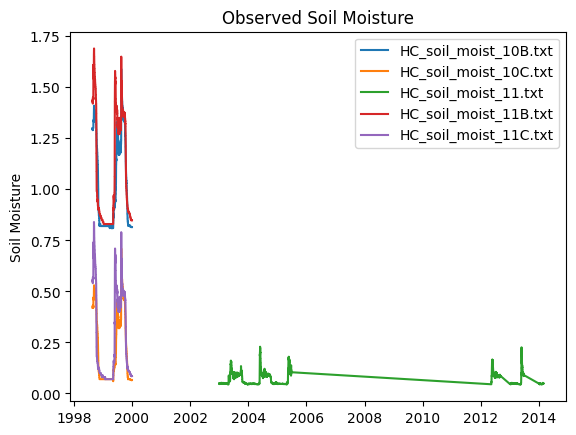

In [10]:
for data in observe:  
    plt.plot(observe[data]["time"], observe[data]["obs_m"], label=f"{data}")
plt.ylabel("Soil Moisture")
plt.title("Observed Soil Moisture")
plt.legend()
plt.show()

In [11]:
var_soilm

<xarray.DataArray 'H2OSOI' (time: 7300, levsoi: 20, lndgrid: 1)> Size: 584kB
[146000 values with dtype=float32]
Coordinates:
  * time     (time) object 58kB 1995-01-01 00:00:00 ... 2014-12-31 00:00:00
  * levsoi   (levsoi) float32 80B 0.01 0.04 0.09 0.16 ... 5.06 5.95 6.94 8.03
Dimensions without coordinates: lndgrid
Attributes:
    long_name:      volumetric soil water (natural vegetated and crop landuni...
    units:          mm3/mm3
    cell_methods:   time: mean
    landunit_mask:  veg

Units are actually the same and the initial graph looks fine so no conversion or cleaning needed, but I'm just gonna stick with one file cause its infinitely more complete.

In [12]:
for x in observe:
    print(x)

HC_soil_moist_10B.txt
HC_soil_moist_10C.txt
HC_soil_moist_11.txt
HC_soil_moist_11B.txt
HC_soil_moist_11C.txt


In [13]:
usable_list = [observe["HC_soil_moist_11C.txt"], observe["HC_soil_moist_11.txt"]]
obs_concat = pd.concat(usable_list, ignore_index=True, sort=True)
print(obs_concat)

       obs_m                      time
0      0.550 1998-08-24 02:30:00+00:00
1      0.550 1998-08-24 03:00:00+00:00
2      0.560 1998-08-24 03:30:00+00:00
3      0.550 1998-08-24 04:00:00+00:00
4      0.560 1998-08-24 04:30:00+00:00
...      ...                       ...
84757  0.048 2014-02-26 19:00:00+00:00
84758  0.048 2014-02-26 19:30:00+00:00
84759  0.048 2014-02-26 20:00:00+00:00
84760  0.048 2014-02-26 20:30:00+00:00
84761  0.048 2014-02-26 21:00:00+00:00

[84762 rows x 2 columns]


## CTSM Interpolation

CTSM reports values at layer midpoints. This means for values like 10, I need to linearly interpolate to get the correct moisture values.

C:\Users\madel\AppData\Local\Temp\ipykernel_10460\3360439478.py:1: FutureWarning: In a future version, xarray will not decode the variable 'SNOW_PERSISTENCE' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.
  ds = xr.open_dataset("HC_1995-2014.nc", engine="netcdf4")


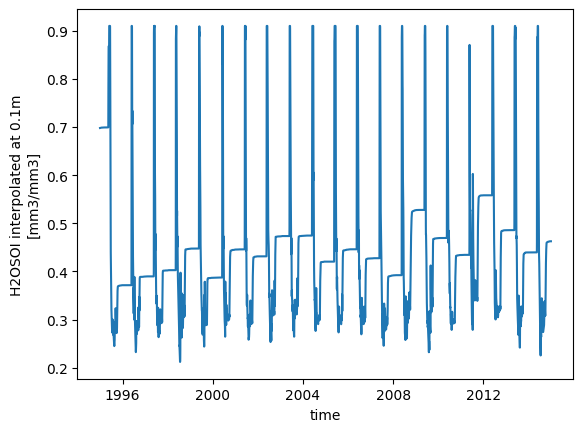

In [14]:
ds = xr.open_dataset("HC_1995-2014.nc", engine="netcdf4")

def interpolate_to_depth(ds, var, target_depth, depth_dim="levsoi"):
    sm = ds[var].squeeze()
    depths = ds[depth_dim].values.flatten()
    
    # Convert CFTime to pandas datetime here, once
    cf_times = ds.indexes['time']
    time = pd.to_datetime([f"{t.year}-{t.month:02d}-{t.day:02d}" 
                           for t in cf_times])
    
    # Interpolate
    idx = int(np.searchsorted(depths, target_depth, side="right") - 1)
    idx = int(np.clip(idx, 0, len(depths) - 2))
    z0, z1 = depths[idx], depths[idx + 1]
    w = (target_depth - z0) / (z1 - z0)
    sm_interp = ((1 - w) * sm.values[:, idx] + w * sm.values[:, idx + 1]).flatten()
    
    return xr.DataArray(
        sm_interp,
        coords={"time": time},
        dims=["time"],
        attrs={"units": ds[var].attrs.get("units", ""), 
               "long_name": f"{var} interpolated at {target_depth}m"},
    )

# Usage
da_interp = interpolate_to_depth(ds, "H2OSOI", target_depth=0.10)
  
da_interp.plot()

checking the interpolation, not expecing much change, but its good to look at.

EDIT: checking in this way doesn't work right now because of how the time is assigned to work with pandas. Should be fixed later, but at the moment this is what we're going with

In [15]:
sim = da_interp
# sim2 = var_soilm.isel(levsoi=2)
# sim3 = var_soilm.isel(levsoi=3)

# sim.plot(color = 'r')
# sim2.plot(color = 'b')
# sim3.plot(color = 'g')
# plt.show()


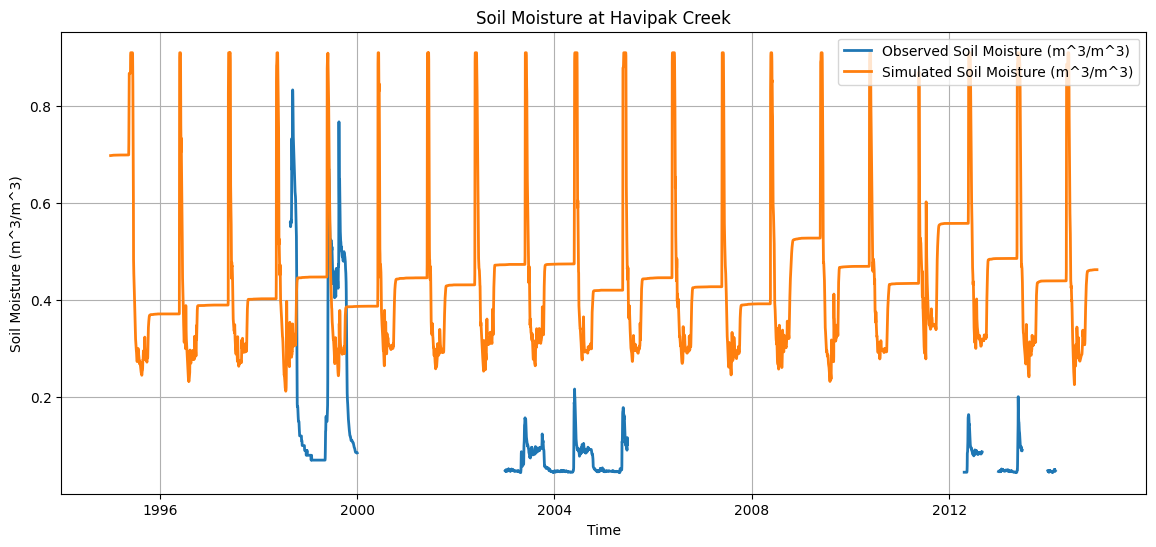

In [16]:
# Convert pandas → xarray
obs = obs_concat.set_index("time").to_xarray()

# Resample observational data to daily frequency
obs_daily = obs.resample(time="1D").mean()


plt.figure(figsize=(14,6))

# Observed (daily)
plt.plot(
    obs_daily["time"].values,
    obs_daily["obs_m"].values,
    label="Observed Soil Moisture (m^3/m^3)",
    linewidth=2
)

# Simulated
plt.plot(
    sim["time"].values,
    sim.values,
    label="Simulated Soil Moisture (m^3/m^3)",
    linewidth=2
)

plt.xlabel("Time")
plt.ylabel("Soil Moisture (m^3/m^3)")
plt.title("Soil Moisture at Havipak Creek")
plt.grid(True)
plt.legend()
plt.savefig("0_final_images/HC_soil_moisture.png")
plt.show()